Title: LEE_Detection.ipynb

Purpose: 

Author: Onno Nennecke on 21.03.2025 Modified: 21.03.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

In [25]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob

In [26]:
# Importing functions


### Read Model output data

In [38]:
files

['/climca/people/onennecke/model_output/winter_data/UKESM1-0-LL_r4i1p1f2_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/EC-Earth3_r128i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/KACE-1-0-G_r3i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/EC-Earth3_r145i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/EC-Earth3_r132i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/ACCESS-CM2_r4i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/EC-Earth3_r118i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/UKESM1-0-LL_r18i1p1f2_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/MRI-ESM2-0_r2i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/MPI-ESM1-2-HR_r7i1p1f1_timeseries_win.nc',
 '/climca/people/onennecke/model_output/winter_data/MPI-ESM1-2-HR_r6i1

In [46]:
tst = xr.open_dataset('/climca/people/onennecke/model_output/winter_data/CESM2_r4i1p1f1_timeseries_win.nc')
tst.ESM.values

array('CESM2', dtype='<U5')

In [49]:
path = '/climca/people/onennecke/model_output/winter_data/'
files = glob.glob(os.path.join(path, '*.nc'))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')
# files

In [50]:
ts_datasets

<xarray.Dataset> Size: 20MB
Dimensions:        (ESM_run: 99, time: 1820)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            (ESM_run) <U10 4kB 'r4i1p1f2' 'r128i1p1f1' ... 'r1i1p1f2'
    ESM            (ESM_run) <U13 5kB 'UKESM1-0-LL' ... 'UKESM1-0-LL'
  * ESM_run        (ESM_run) <U23 9kB 'UKESM1-0-LL_r4i1p1f2' ... 'UKESM1-0-LL...
    winter_year    (ESM_run, time) int64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    day_of_winter  (ESM_run, time) int64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    winter_season  (ESM_run, time) <U8 6MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
Data variables:
    temp           (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand         (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto          (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 1MB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [51]:
np.unique(ts_datasets.ESM)

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1',
       'UKESM1-0-LL'], dtype='<U13')

In [ ]:
ts_datasets_CESM = ts_datasets.where(ts_datasets.ESM == 'CESM2', drop=True)

ts_datasets_CESM

<xarray.Dataset> Size: 627kB
Dimensions:        (ESM_run: 3, time: 1820)
Coordinates:
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            (ESM_run) <U10 120B 'r4i1p1f1' 'r11i1p1f1' 'r10i1p1f1'
    ESM            (ESM_run) <U13 156B 'CESM2' 'CESM2' 'CESM2'
  * ESM_run        (ESM_run) <U23 276B 'CESM2_r4i1p1f1' ... 'CESM2_r10i1p1f1'
    winter_year    (ESM_run, time) int64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    day_of_winter  (ESM_run, time) int64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    winter_season  (ESM_run, time) <U8 175kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
Data variables:
    temp           (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    demand         (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_off_prod  (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    wind_on_prod   (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    solar_prod     (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    total_prod     (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Netto          (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>
    Residual_load  (ESM_run, time) float64 44kB dask.array<chunksize=(1, 1820), meta=np.ndarray>

In [ ]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
           'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# ESMs = ['CESM2']
# ESMs = ['TaiEMS1', 'UKESM1-0LL']
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
# variables = ['sfcWind'] # List of variables

grid_def = '*'
version = '*'


In [17]:
ESM = ESMs[0]
run = 'r4i1p1f1'


In [18]:
path = f'/climca/people/onennecke/model_output/{ESM}_{run}_timeseries.nc'
timeseries_ds = xr.open_dataset(path)

In [10]:
timeseries_ds = ts_datasets.sel(ESM_run = ts_datasets.ESM_run[0])

In [11]:
timeseries_ds

<xarray.Dataset> Size: 219kB
Dimensions:        (time: 1820)
Coordinates:
  * time           (time) datetime64[ns] 15kB 2015-01-01T12:00:00 ... 2024-12...
    crs            int64 8B 4326
    gridtype       <U6 24B 'lonlat'
    country        float64 8B 9.0
    period         <U4 16B 'week'
    run            <U10 40B 'r145i1p1f1'
    ESM            <U13 52B 'EC-Earth3'
    ESM_run        <U23 92B 'EC-Earth3_r145i1p1f1'
    winter_year    (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    day_of_winter  (time) int64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    winter_season  (time) <U8 58kB dask.array<chunksize=(1820,), meta=np.ndarray>
Data variables:
    temp           (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    demand         (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    wind_off_prod  (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    wind_on_prod   (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    solar_prod     (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    total_prod     (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    Netto          (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>
    Residual_load  (time) float64 15kB dask.array<chunksize=(1820,), meta=np.ndarray>

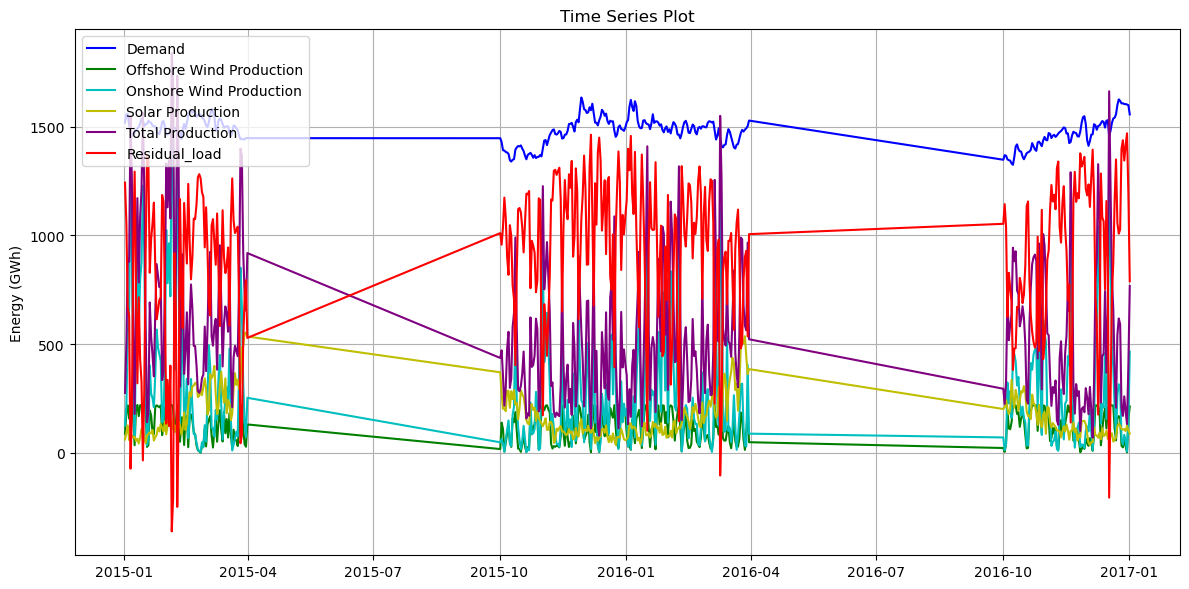

In [24]:

# Define your slice (adjust these to your desired time range)
a = 191 + 365 * 81
b = 7 + 365 * 82
a = 0 #365 * 1
b = 365 * 1

# Extract time and variables for the chosen range
time = timeseries_ds['time'][a:b] # winter_season
demand = timeseries_ds['demand'][a:b]
wind_off = timeseries_ds['wind_off_prod'][a:b]
wind_on = timeseries_ds['wind_on_prod'][a:b]
solar = timeseries_ds['solar_prod'][a:b]
total_prod = timeseries_ds['total_prod'][a:b]
Residual_load = timeseries_ds['Residual_load'][a:b]

# Create the figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each variable
ax.plot(time, demand, label='Demand', color='b')
ax.plot(time, wind_off, label='Offshore Wind Production', color='g')
ax.plot(time, wind_on, label='Onshore Wind Production', color='c')
ax.plot(time, solar, label='Solar Production', color='y')
ax.plot(time, total_prod, label='Total Production', color='purple')
ax.plot(time, Residual_load, label='Residual_load', color='r')

# Reduce the number of x-axis labels
# from matplotlib.ticker import MaxNLocator
# ax.xaxis.set_major_locator(MaxNLocator(nbins=10))  # Adjust nbins as needed

# Labeling
ax.set_xlabel('')
ax.set_ylabel('Energy (GWh)')
ax.set_title('Time Series Plot')
ax.legend()

# Formatting
fig.tight_layout()
plt.grid(True)
plt.show()



#### Identification of low energy events